<a href="https://colab.research.google.com/github/neurostatslab/error-in-variables-garon-2026/blob/main/demo_notebooks/002_dynamiceiv_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
!git clone https://github.com/neurostatslab/error-in-variables-garon-2026.git
import sys
sys.path.append('error-in-variables-garon-2026/')

!pip install -q "jax[cuda12]==0.6.0" "jaxlib==0.6.0" optax tensorflow-probability

import jax
from jax import config
config.update("jax_enable_x64", True)

import jax.numpy as jnp
import optax
from tensorflow_probability.substrates import jax as tfp
tfd = tfp.distributions

import time

import utils
from core import DynamicEIV

fatal: destination path 'error-in-variables-garon-2026' already exists and is not an empty directory.


# Fit Model

### Construct Model Params

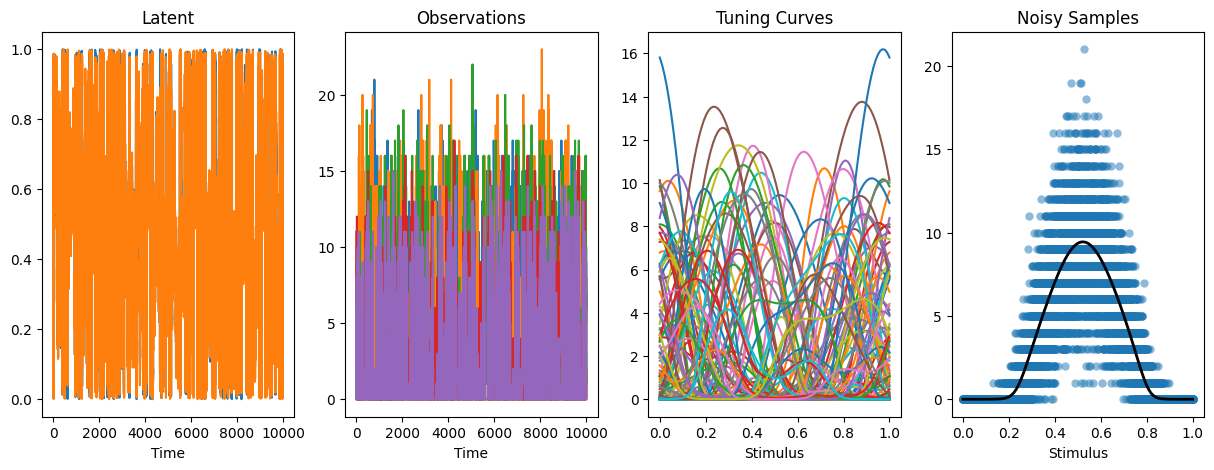

In [5]:
# Generative Hyperparams

num_neurons = 100
num_dims = 1
num_steps = 10000


# Construct Model
model = DynamicEIV(len_scale = .2,
            out_scale = 50.,
            kappa = 20.,
            proposal_concentration=15.,
            num_dims=num_dims,
            num_neurons=num_neurons)

# Simulate Data
xs_true, y_and_s = model.simulate(
    num_steps=num_steps, key = jax.random.PRNGKey(7)
)

# Visualize Data
utils.plot_simulated_data_1D(xs_true, model.true_params, y_and_s, model);

### Fit Model

In [ ]:
opt_params = {
        "opt_key": jax.random.PRNGKey(123),
        "init_key": jax.random.PRNGKey(456),
        "tol_loss":1e-4,
        "batch_size":2000,
        "lr": 1e01
    }

model.fit(y_and_s, "adam", opt_params)


### Plot Results

In [ ]:
utils.plot_objhist(model);


x_grid = utils.make_xgrid(1, 100, 1.)
true_tunings = model.observation.mapping(model.true_params, x_grid)[0].T
utils.plot_real_tuning(model, true_tunings, y_and_s)

utils.plot_latent_recon_sim(model, y_and_s, xs_true)